In [ ]:
!pip install trl
!pip install -U bitsandbytes>=0.46.1
!pip install unsloth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.8/760.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 1. Import Libraries

In [ ]:
from unsloth import FastLanguageModel

from datasets import load_dataset

import json
import os
import re

from trl import SFTTrainer, SFTConfig

from peft import LoraConfig, get_peft_model

import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# 2. Load Dataset

In [ ]:
MODEL_NAME = "unsloth/meta-llama-3.1-8b-Instruct-bnb-4bit"
max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

==((====))==  Unsloth 2026.5.7: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-Instruct-bnb-4bit as a legacy tokenizer.


In [ ]:
print("Importing Dataset ...")

dataset_icliniq = load_dataset("lavita/ChatDoctor-iCliniq", split="train")

print(f"icliniq: {len(dataset_icliniq)} samples")

Importing Dataset ...


README.md:   0%|          | 0.00/581 [00:00<?, ?B/s]

data/train-00000-of-00001-7f15f39e4c3a7e(…):   0%|          | 0.00/9.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7321 [00:00<?, ? examples/s]

icliniq: 7321 samples


In [ ]:
dataset_icliniq

Dataset({
    features: ['input', 'answer_icliniq', 'answer_chatgpt', 'answer_chatdoctor'],
    num_rows: 7321
})

# 3. Data Preprocessing

In [ ]:
def clean_text(text):
    if not text: return ""
    return re.sub(r'\s+', ' ', text).strip()

In [ ]:
def preprocess_icliniq(examples):
    formatted_texts = []
    batch_size = len(examples["input"])

    for i in range(batch_size):
        patient_query = clean_text(examples["input"][i])

        doctor_response = examples["answer_chatdoctor"][i]
        if not doctor_response:
            doctor_response = examples["answer_chatgpt"][i]

        doctor_response = clean_text(doctor_response)

        if not patient_query or not doctor_response:
            continue

        messages = [
            {
                "role": "system",
                "content": "You are an expert, professional, and deeply empathetic AI Medical Assistant. Analyze the patient's symptoms carefully, provide potential clinical insights, and suggest immediate precautions. Strictly Disclaimer: This is for informational purposes only, not a substitute for professional medical advice."
            },
            {"role": "user", "content": patient_query},
            {"role": "assistant", "content": doctor_response}
        ]

        formatted_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        formatted_texts.append(formatted_text)

    return {"text": formatted_texts}

In [ ]:
print("Processing Data ...")

dataset_ic_clean = dataset_icliniq.map(
    preprocess_icliniq,
    batched=True,
    remove_columns=dataset_icliniq.column_names,
    num_proc=4
)

split_dataset = dataset_ic_clean.train_test_split(test_size=0.1, seed=3407)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print("-" * 40)
print(f"Total samples: {len(dataset_ic_clean)}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print("-" * 40)

Processing Data ...


Map (num_proc=4):   0%|          | 0/7321 [00:00<?, ? examples/s]

----------------------------------------
Total samples: 7321
Training samples:   6588
Validation samples: 733
----------------------------------------


# 4. Fine-tuning Llama-3-8b-Instruct

## 4.1 Configure LoRA

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

Unsloth 2026.5.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


## 4.2 Configure Training Arguments

In [ ]:
training_args = SFTConfig(
    output_dir = "outputs_medical_llama3",

    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,

    learning_rate = 2e-4,
    warmup_steps = 50,
    num_train_epochs = 1,

    logging_steps = 10,

    eval_strategy = "steps",
    eval_steps = 50,
    per_device_eval_batch_size = 2,

    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),

    optim = "adamw_8bit",

    weight_decay = 0.01,
    lr_scheduler_type = "linear",

    seed = 3407,
    report_to = "none",

    dataset_text_field = "text",

    max_seq_length = max_seq_length,
    packing = False,
)

## 4.3 Configure SFT Trainer

In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    args = training_args,
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6588 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/733 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


## 4.4 Fine-tuning

In [ ]:
print("--- Fine-tuning Process ... ---")

trainer_stats = trainer.train()

--- Fine-tuning Process ... ---


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,588 | Num Epochs = 1 | Total steps = 824
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,1.456314,1.363696
100,1.327285,1.304922
150,1.259088,1.287506
200,1.329421,1.275394
250,1.338769,1.264826
300,1.300478,1.258682
350,1.286269,1.252752
400,1.304795,1.247697
450,1.236458,1.243631
500,1.312892,1.238601


Unsloth: Restored added_tokens_decoder metadata in outputs_medical_llama3/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_medical_llama3/checkpoint-824/tokenizer_config.json.


In [ ]:
model.push_to_hub("ntq05/medical-llama3-lora", token = "")
tokenizer.push_to_hub("ntq05/medical-llama3-lora", token = "")

README.md:   0%|          | 0.00/573 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  555kB /  168MB            

Saved model to https://huggingface.co/ntq05/medical-llama3-lora


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpw0_38luf/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpw0_38luf/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

# 5. Visualizing Training and Testing Loss

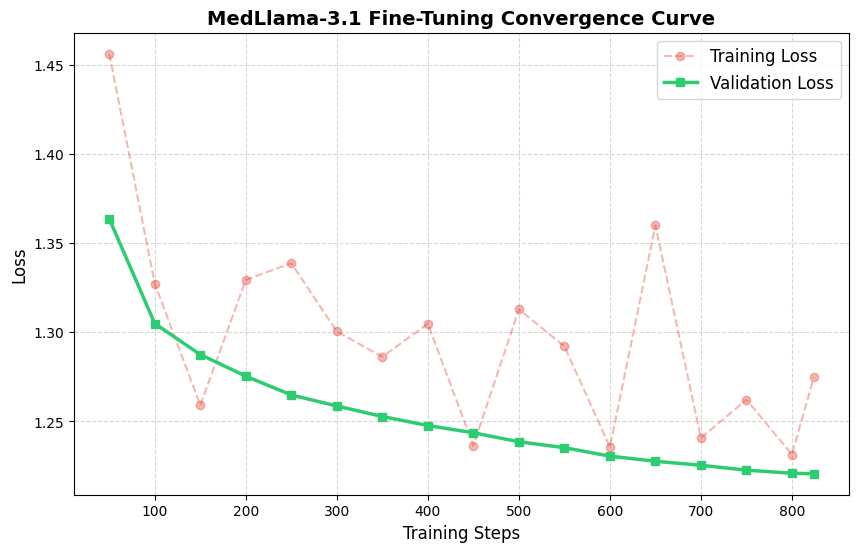

In [ ]:
import matplotlib.pyplot as plt

steps = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 824]
train_loss = [1.456314, 1.327285, 1.259088, 1.329421, 1.338769, 1.300478, 1.286269, 1.304795, 1.236458, 1.312892, 1.292147, 1.235640, 1.360041, 1.240655, 1.262234, 1.231415, 1.274744]
val_loss = [1.363696, 1.304922, 1.287506, 1.275394, 1.264826, 1.258682, 1.252752, 1.247697, 1.243631, 1.238601, 1.235256, 1.230527, 1.227647, 1.225396, 1.222662, 1.220929, 1.220656]

plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label="Training Loss", color="#e74c3c", alpha=0.4, linestyle="--", marker="o")
plt.plot(steps, val_loss, label="Validation Loss", color="#2ecc71", linewidth=2.5, marker="s")

plt.title("MedLlama-3.1 Fine-Tuning Convergence Curve", fontsize=14, fontweight='bold')
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.savefig("medllama_loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()